In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Data Preprocessing:

In [25]:
df = pd.read_csv("anime.csv")
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [26]:
df.shape

(12294, 7)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [28]:
df.describe(include='all')

,anime_id,name,genre,type,episodes,rating,members
count,12294.000000,12294,12232,12269,12294,12064.000000,1.229400e+04
unique,NaN,12292,3264,6,187,NaN,NaN
top,NaN,Shi Wan Ge Leng Xiaohua,Hentai,TV,1,NaN,NaN
freq,NaN,2,823,3787,5677,NaN,NaN
mean,14058.221653,NaN,NaN,NaN,NaN,6.473902,1.807134e+04
std,11455.294701,NaN,NaN,NaN,NaN,1.026746,5.482068e+04
min,1.000000,NaN,NaN,NaN,NaN,1.670000,5.000000e+00
25%,3484.250000,NaN,NaN,NaN,NaN,5.880000,2.250000e+02
50%,10260.500000,NaN,NaN,NaN,NaN,6.570000,1.550000e+03
75%,24794.500000,NaN,NaN,NaN,NaN,7.180000,9.437000e+03


In [29]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [44]:
# Handle missing values
df['genre'] = df['genre'].fillna('Unknown')
df['type'] = df['type'].fillna(df['type'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].median())
# Convert episodes to numeric
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
# Fill NaN values created during conversion
df['episodes'] = df['episodes'].fillna(df['episodes'].median())

# Check missing values
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

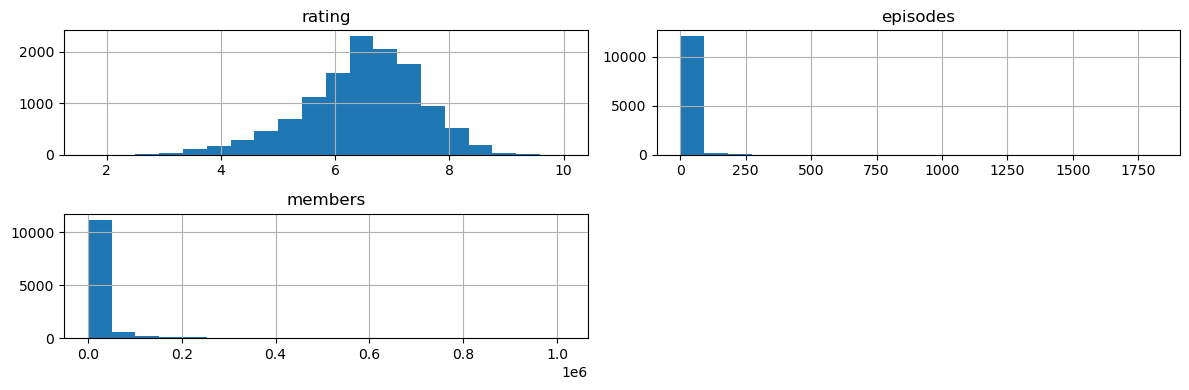

In [45]:
#Histogram
num_cols = ['rating', 'episodes', 'members']
df[num_cols].hist(figsize=(12,4), bins=20)

plt.tight_layout()
plt.show()

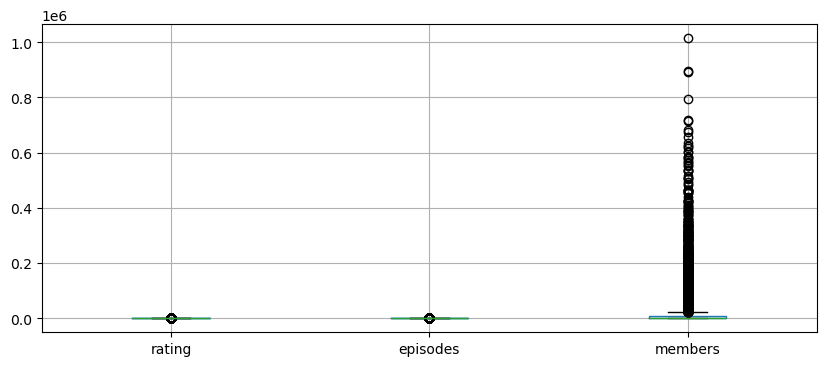

In [46]:
#Box Plot
plt.figure(figsize=(10,4))
df[num_cols].boxplot()

plt.show()

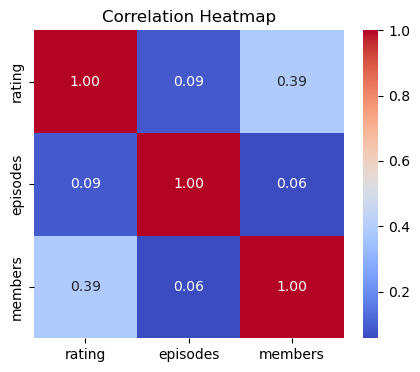

In [47]:
#Correlation HeatMap
plt.figure(figsize=(5,4))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Task 2: Feature Extraction

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

In [49]:
#TF-IDF Vectorization of Genre

In [50]:
tfidf = TfidfVectorizer(stop_words='english')
genre_matrix = tfidf.fit_transform(df['genre'])
print(genre_matrix.shape)

(12294, 47)


In [52]:
# Normalizing Numerical Features

In [53]:

scaler = StandardScaler()
numeric_features = scaler.fit_transform(
    df[['rating', 'episodes', 'members']]
)

numeric_features.shape

(12294, 3)

In [ ]:
# Combining Genre and Numerical Features

In [54]:
from scipy.sparse import hstack

feature_matrix = hstack([genre_matrix, numeric_features])
feature_matrix.shape

(12294, 50)

In [55]:
# Compute Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(feature_matrix)
print(cosine_sim.shape)

(12294, 12294)


In [56]:
# Creating Index Mapping
indices = pd.Series(df.index, index=df['name']).drop_duplicates()
indices.head()

name
Kimi no Na wa.                      0
Fullmetal Alchemist: Brotherhood    1
Gintama°                            2
Steins;Gate                         3
Gintama&#039;                       4
dtype: int64

# Task 3: Recommendation System

In [57]:
def recommend_anime(anime_name, cosine_sim=cosine_sim, threshold=0.5, top_n=10):

    # Check if anime exists
    if anime_name not in indices:
        return "Anime not found in the dataset."

    idx = indices[anime_name]
    # Similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    # Remove the same anime
    sim_scores = [(i, score) for i, score in sim_scores if i != idx]
    # Apply threshold
    sim_scores = [x for x in sim_scores if x[1] >= threshold]
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Top recommendations
    sim_scores = sim_scores[:top_n]
    anime_indices = [i[0] for i in sim_scores]
    recommendations = df.iloc[anime_indices][
        ['name', 'genre', 'rating', 'episodes']
    ].copy()

    recommendations['Similarity Score'] = [x[1] for x in sim_scores]

    return recommendations

In [59]:
# Test Recommendation
recommend_anime("Naruto")

,name,genre,rating,episodes,Similarity Score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,175.0,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,103.0,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,64.0,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,148.0,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,153.0,0.972025
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",7.95,366.0,0.967331
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.08,51.0,0.957075
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33,51.0,0.955219
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,64.0,0.954936
255,Fairy Tail (2014),"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.25,102.0,0.949190


In [66]:
# Experiment with Different Thresholds Threshold = 0.30
recommend_anime("Naruto", threshold=0.30)

,name,genre,rating,episodes,Similarity Score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,175.0,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,103.0,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,64.0,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,148.0,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,153.0,0.972025
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",7.95,366.0,0.967331
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.08,51.0,0.957075
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33,51.0,0.955219
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,64.0,0.954936
255,Fairy Tail (2014),"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.25,102.0,0.949190


In [61]:
recommend_anime("Naruto", threshold=0.50)

,name,genre,rating,episodes,Similarity Score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,175.0,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,103.0,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,64.0,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,148.0,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,153.0,0.972025
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",7.95,366.0,0.967331
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.08,51.0,0.957075
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33,51.0,0.955219
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,64.0,0.954936
255,Fairy Tail (2014),"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.25,102.0,0.949190


In [62]:
recommend_anime("Naruto", threshold=0.70)

,name,genre,rating,episodes,Similarity Score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,175.0,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,103.0,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,64.0,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,148.0,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,153.0,0.972025
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",7.95,366.0,0.967331
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.08,51.0,0.957075
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33,51.0,0.955219
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,64.0,0.954936
255,Fairy Tail (2014),"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.25,102.0,0.949190


In [91]:
thresholds = [0.3, 0.5, 0.7]
idx = indices["Naruto"]
sim_scores = cosine_sim[idx]

for t in thresholds:
    count = sum(sim_scores >= t) - 1   # Exclude the anime itself
    print(f"Threshold {t}: {count} recommendations")

Threshold 0.3: 1426 recommendations
Threshold 0.5: 966 recommendations
Threshold 0.7: 572 recommendations


### Observation:
- Lower threshold (0.30): Returns more recommendations, but they may be less similar.
- Medium threshold (0.50): Provides a balanced number of relevant recommendations.
- Higher threshold (0.70): Returns fewer but highly similar anime.

### Analyze the Performance of the Recommendation System 
- The recommendation system successfully suggests anime with similar genres and characteristics using cosine similarity.
- Lower similarity thresholds generate more recommendations, while higher thresholds return fewer but more relevant anime.
- The quality of recommendations depends on the selected features (genre, rating, episodes, and members) and the chosen similarity threshold.
### Areas of Improvement:
- Include user ratings and viewing history to build a collaborative or hybrid recommendation system.
- Use additional features such as studios, producers, release year, and synopsis to improve recommendation accuracy.
- Apply advanced embedding techniques (e.g., Word2Vec or BERT) instead of TF-IDF to capture deeper semantic similarities between anime.

### 1. Can you explain the difference between user-based and item-based collaborative filtering?

User-based collaborative filtering recommends items based on the preferences of users with similar interests.
Item-based collaborative filtering recommends items that are similar to the items a user has previously liked or interacted with.
User-based focuses on user similarity, whereas item-based focuses on item similarity and is generally more scalable.

###  2. What is collaborative filtering, and how does it work?

Collaborative filtering is a recommendation technique that predicts user preferences based on the behavior of many users.
It identifies patterns in user-item interactions and recommends items that similar users liked or similar items to those already preferred.It can be implemented using user-based or item-based similarity to generate personalized